In [1]:
## data visualisations - q-transform spectrograms

## visualizes gravitational wave signals unsing q-transform

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import butter, filtfilt
import glob
import os

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 10

BASE_DIR    = r'C:\Users\srika\gw_wd'
EVENTS_DIR  = os.path.join(BASE_DIR, 'data', 'events')
NOISE_DIR   = os.path.join(BASE_DIR, 'data', 'noise')
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Preprocessing Functions ───────────────────────────────

def bandpass_filter(data, lowcut=30, highcut=400, fs=4096, order=4):
    """
    Bandpass filter to focus on GW frequency range
    Gravitational waves are typically between 30-400 Hz
    """
    nyq    = fs / 2
    low    = lowcut  / nyq
    high   = highcut / nyq
    b, a   = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)


def whiten(data, fs=4096):
    """
    Whiten the data to normalize noise across frequencies
    This is the KEY step that makes GW signals visible!
    """
    # Compute FFT
    N        = len(data)
    freqs    = np.fft.rfftfreq(N, d=1/fs)
    fft_data = np.fft.rfft(data)
    
    # Estimate power spectral density
    window   = int(fs * 4)
    freqs_psd, psd = signal.welch(data, fs=fs, nperseg=window)
    
    # Interpolate PSD to FFT frequencies
    psd_interp = np.interp(freqs, freqs_psd, psd)
    psd_interp = np.maximum(psd_interp, 1e-50)  # Avoid division by zero
    
    # Whiten: divide by sqrt of PSD
    whitened_fft  = fft_data / np.sqrt(psd_interp)
    whitened_data = np.fft.irfft(whitened_fft, n=N)
    
    return whitened_data


def preprocess(data, fs=4096, lowcut=30, highcut=400):
    """
    Full preprocessing pipeline:
    1. Whiten (normalize noise)
    2. Bandpass filter (focus on GW range)
    """
    whitened = whiten(data, fs=fs)
    filtered = bandpass_filter(whitened, lowcut=lowcut, 
                                highcut=highcut, fs=fs)
    return filtered


print(" Imports and preprocessing functions ready!")

 Imports and preprocessing functions ready!


In [11]:
def load_event(event_name, detector='H1'):
    filepath = os.path.join(EVENTS_DIR, f'{event_name}_{detector}.npy')
    metapath = os.path.join(EVENTS_DIR, f'{event_name}_{detector}_meta.npy')
    data     = np.load(filepath)
    meta     = np.load(metapath, allow_pickle=True).item()
    return data, meta

def load_noise(index, detector='H1'):
    filepath = os.path.join(NOISE_DIR, f'noise_{index:03d}_{detector}.npy')
    metapath = os.path.join(NOISE_DIR, f'noise_{index:03d}_{detector}_meta.npy')
    data     = np.load(filepath)
    meta     = np.load(metapath, allow_pickle=True).item()
    return data, meta

def get_time_array(data, sample_rate):
    return np.linspace(0, len(data)/sample_rate, len(data))

# Load GW150914
data_h1, meta_h1 = load_event('GW150914', 'H1')
data_l1, meta_l1 = load_event('GW150914', 'L1')

sr   = meta_h1['sample_rate']
time = get_time_array(data_h1, sr)

print(" Data loaded!")
print(f"   Sample rate: {sr} Hz")
print(f"   Samples    : {len(data_h1):,}")
print(f"   Duration   : {meta_h1['duration']} seconds")


 Data loaded!
   Sample rate: 4096.0 Hz
   Samples    : 131,072
   Duration   : 32 seconds


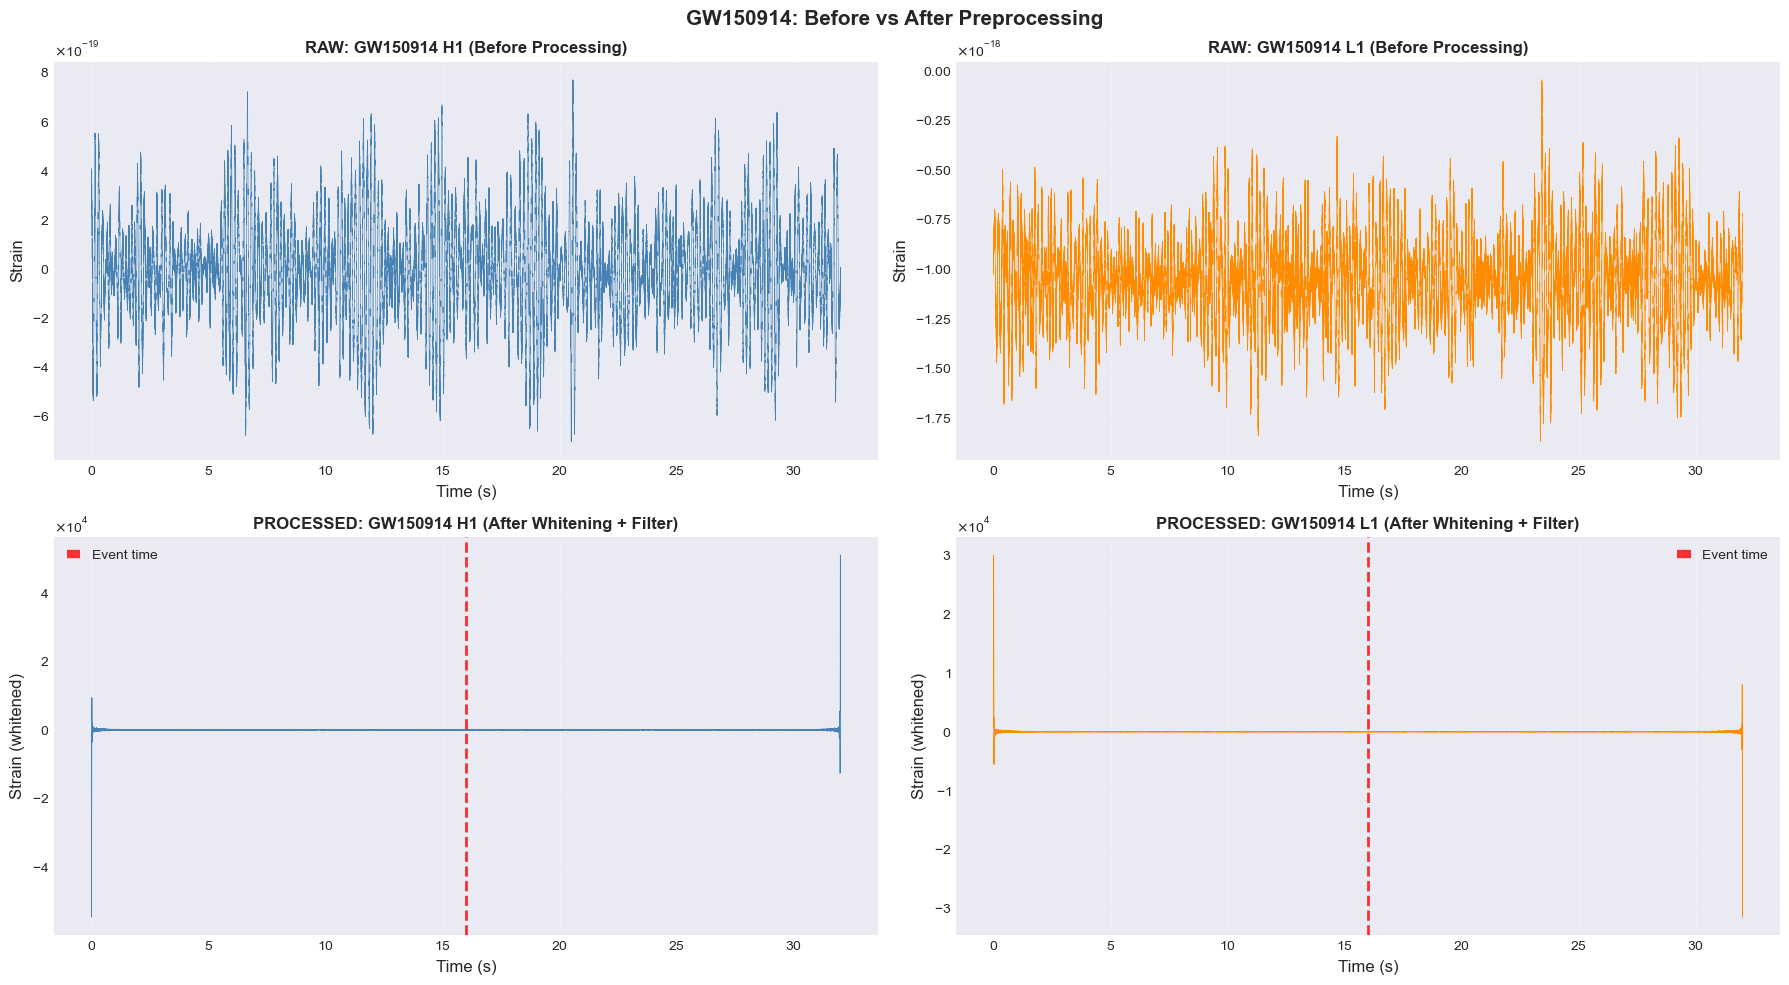

 Saved: 01_before_after.png

 After processing you should see a clear spike around t=16s!


In [12]:
# Process the data
processed_h1 = preprocess(data_h1, fs=sr)
processed_l1 = preprocess(data_l1, fs=sr)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── Raw data ──────────────────────────────────────────────
axes[0,0].plot(time, data_h1, linewidth=0.4, color='steelblue')
axes[0,0].set_title('RAW: GW150914 H1 (Before Processing)', 
                     fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Strain')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(time, data_l1, linewidth=0.4, color='darkorange')
axes[0,1].set_title('RAW: GW150914 L1 (Before Processing)',
                     fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Strain')
axes[0,1].grid(True, alpha=0.3)

# ── Processed data ────────────────────────────────────────
axes[1,0].plot(time, processed_h1, linewidth=0.6, color='steelblue')
axes[1,0].axvline(16, color='red', linestyle='--', 
                   linewidth=2, label='Event time', alpha=0.8)
axes[1,0].set_title('PROCESSED: GW150914 H1 (After Whitening + Filter)',
                     fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Strain (whitened)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(time, processed_l1, linewidth=0.6, color='darkorange')
axes[1,1].axvline(16, color='red', linestyle='--',
                   linewidth=2, label='Event time', alpha=0.8)
axes[1,1].set_title('PROCESSED: GW150914 L1 (After Whitening + Filter)',
                     fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('Strain (whitened)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('GW150914: Before vs After Preprocessing',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '01_before_after.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 01_before_after.png")
print("\n After processing you should see a clear spike around t=16s!")

In [13]:
from gwpy.timeseries import TimeSeries
import numpy as np
import matplotlib.pyplot as plt
import os

BASE_DIR    = r'C:\Users\srika\gw_wd'
EVENTS_DIR  = os.path.join(BASE_DIR, 'data', 'events')
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True)

# GPS time of GW150914
gps = 1126259462.4

# Load saved numpy data
data_h1_np = np.load(os.path.join(EVENTS_DIR, 'GW150914_H1.npy'))
meta_h1    = np.load(os.path.join(EVENTS_DIR, 'GW150914_H1_meta.npy'),
                     allow_pickle=True).item()

data_l1_np = np.load(os.path.join(EVENTS_DIR, 'GW150914_L1.npy'))
sr         = meta_h1['sample_rate']

# Convert to gwpy TimeSeries
ts_h1 = TimeSeries(data_h1_np, t0=gps-16, sample_rate=sr, unit='strain')
ts_l1 = TimeSeries(data_l1_np, t0=gps-16, sample_rate=sr, unit='strain')

print(" Data converted to gwpy TimeSeries")
print(f"   Duration : {len(ts_h1)/sr:.0f} seconds")
print(f"   SR       : {sr} Hz")
print(f"   GPS start: {gps-16}")
print(f"   GPS event: {gps}")

 Data converted to gwpy TimeSeries
   Duration : 32 seconds
   SR       : 4096.0 Hz
   GPS start: 1126259446.4
   GPS event: 1126259462.4


COMPUTING Q-TRANSFORM

wait ~60 seconds..

Computing H1 (Hanford)... done
Computing L1 (Livingston)... done


C:\Users\srika\AppData\Local\Temp\ipykernel_5116\4164134069.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\srika\AppData\Local\Temp\ipykernel_5116\4164134069.py:57: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\srika\anaconda3\envs\gw\lib\site-packages\gwpy\plot\axes.py:194: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  super().draw(*args, **kwargs)
C:\Users\srika\AppData\Local\Temp\ipykernel_5116\4164134069.py:58: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) Arial.
  plt.savefig(os.path.join(RESULTS_DIR, '07_qtransform.png'),
C:\Users\srika\AppData\Local\Temp\ipykernel_5116\4164134069.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(RESULTS_DIR, '07_qtransform.png'),
C:\Users\srika\anaconda3\envs\gw\lib\site-packages\IPython\core

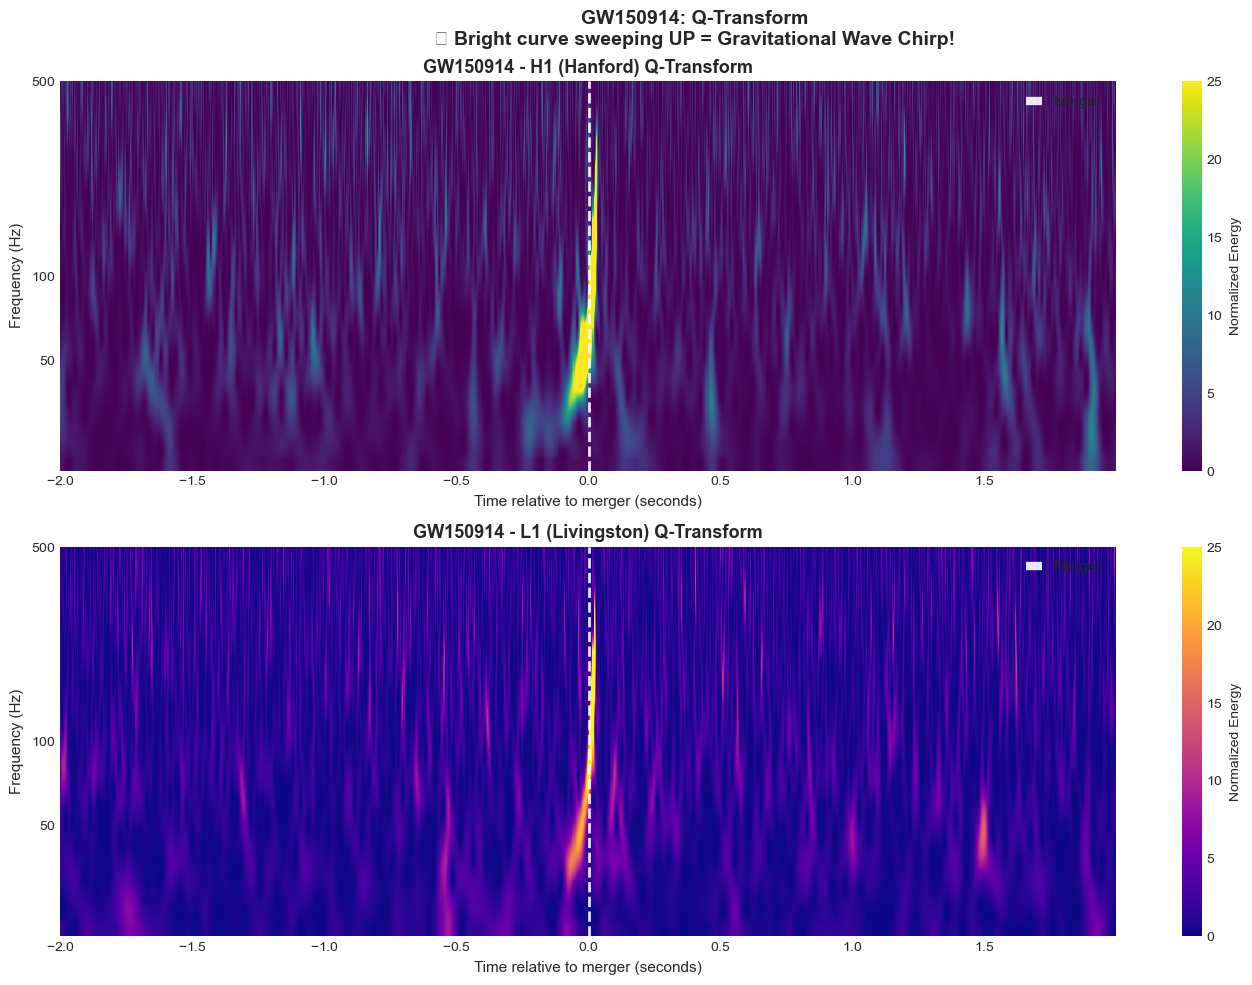


 Saved: 07_qtransform.png
\ You should now see:
  • Bright yellow/white blob sweeping UPWARD
  • Starting around 30-50 Hz at t=-1s
  • Rising to 150+ Hz at t=0 (merger)
  • This IS the gravitational wave from two black holes merging!


In [14]:

print("COMPUTING Q-TRANSFORM\n")

print("wait ~60 seconds..\n")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

datasets = [
    (ts_h1, 'H1 (Hanford)',    'viridis'),
    (ts_l1, 'L1 (Livingston)', 'plasma'),
]

for ax, (ts, detector, cmap) in zip(axes, datasets):
    print(f"Computing {detector}...", end=' ', flush=True)
    
    # Q-transform zoomed to ±2 seconds around merger
    qgram = ts.q_transform(
        frange=(20, 500),
        qrange=(4, 64),
        outseg=(gps - 2, gps + 2),
        logf=True,
        whiten=True         # Built-in whitening!
    )
    
    print("done")
    
    # Get arrays for plotting
    t_vals = qgram.times.value - gps   # Center at 0
    f_vals = qgram.frequencies.value
    power  = qgram.value
    
    im = ax.pcolormesh(
        t_vals,
        f_vals,
        power.T,
        cmap=cmap,
        shading='auto',
        vmin=0,
        vmax=25            # Normalize to show chirp clearly
    )
    
    ax.set_yscale('log')
    ax.set_ylim([20, 500])
    ax.set_title(f'GW150914 - {detector} Q-Transform',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time relative to merger (seconds)', fontsize=11)
    ax.set_ylabel('Frequency (Hz)', fontsize=11)
    ax.axvline(0, color='white', linestyle='--',
               linewidth=2, alpha=0.9, label='Merger')
    ax.legend(fontsize=11)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Normalized Energy', fontsize=10)

plt.suptitle('GW150914: Q-Transform\n'
             '🌊 Bright curve sweeping UP = Gravitational Wave Chirp!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '07_qtransform.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\n Saved: 07_qtransform.png")
print("\ You should now see:")
print("  • Bright yellow/white blob sweeping UPWARD")
print("  • Starting around 30-50 Hz at t=-1s")
print("  • Rising to 150+ Hz at t=0 (merger)")
print("  • This IS the gravitational wave from two black holes merging!")

C:\Users\srika\AppData\Local\Temp\ipykernel_5116\444519561.py:52: RuntimeWarning: invalid value encountered in divide
  whitened_fft  = fft_data / np.sqrt(psd_interp)
C:\Users\srika\AppData\Local\Temp\ipykernel_5116\2027287926.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


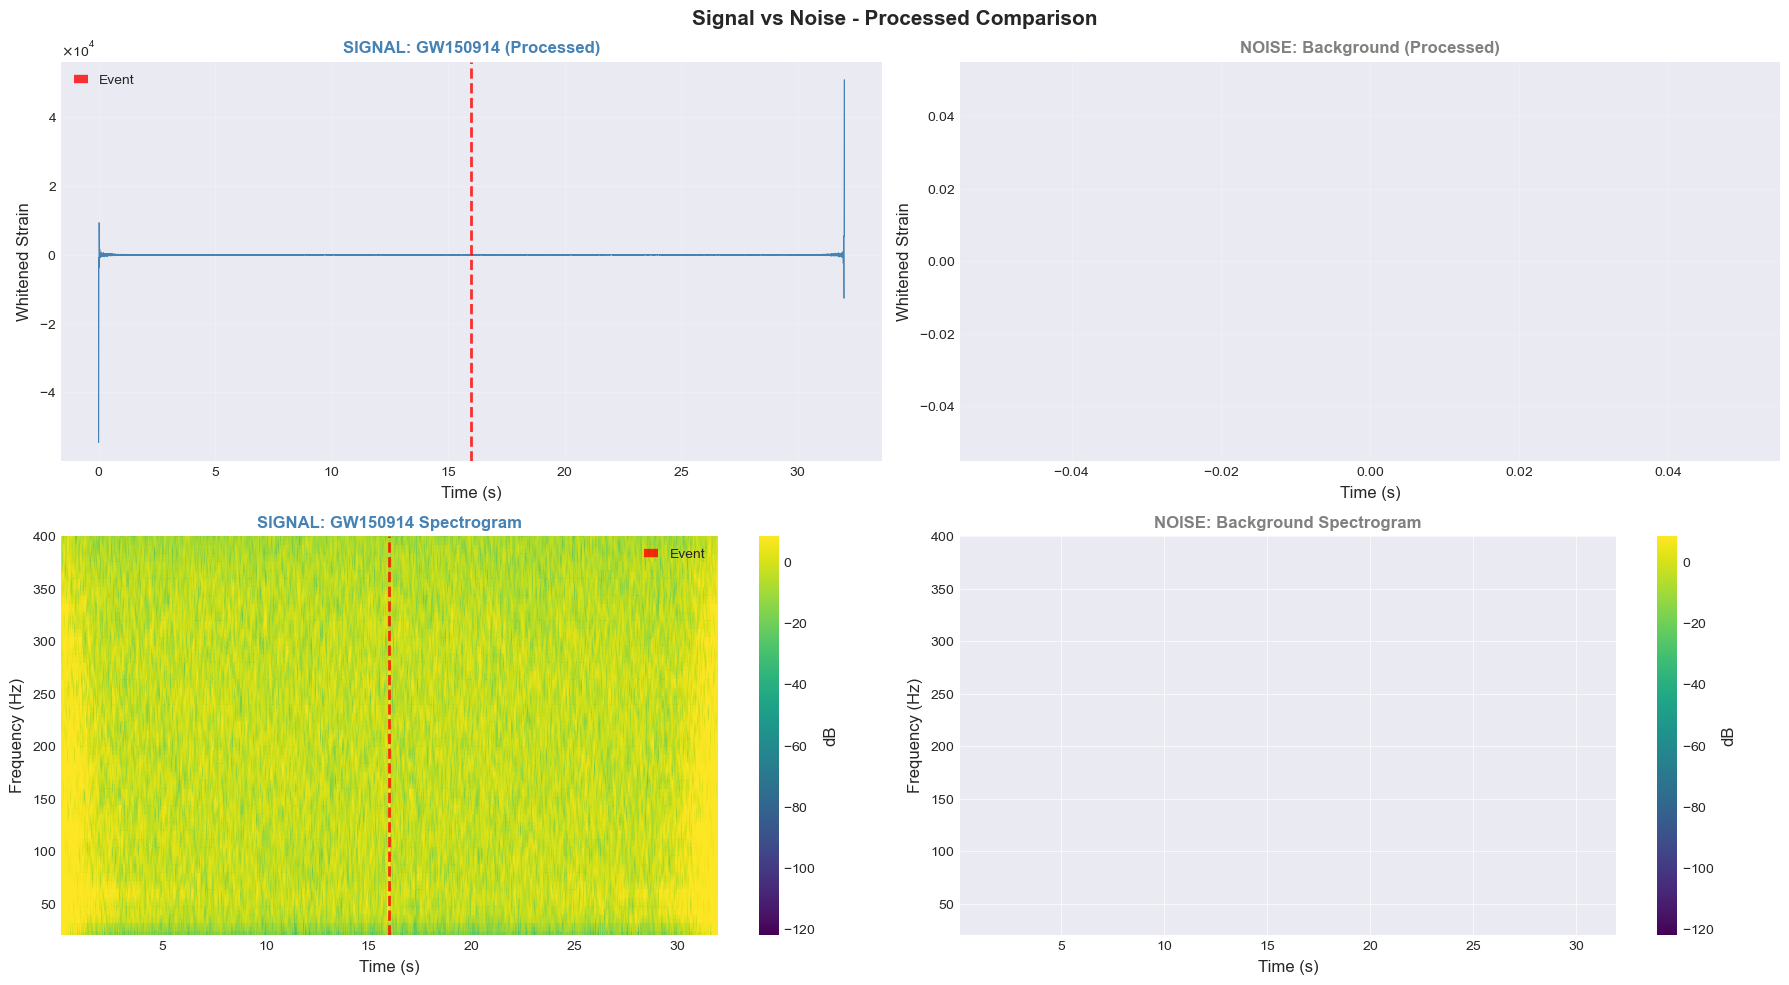

 Saved: 03_signal_vs_noise.png

 Key difference:

   SIGNAL spectrogram → bright chirp pattern visible!

   NOISE spectrogram  → uniform random pattern, no structure


In [15]:
# Load and process noise
noise_raw, noise_meta = load_noise(1, 'H1')
noise_processed       = preprocess(noise_raw, fs=noise_meta['sample_rate'])
noise_time            = get_time_array(noise_raw, noise_meta['sample_rate'])

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── Time Series ───────────────────────────────────────────
axes[0,0].plot(time, processed_h1, linewidth=0.6, color='steelblue')
axes[0,0].axvline(16, color='red', linestyle='--', linewidth=2, 
                   alpha=0.8, label='Event')
axes[0,0].set_title('SIGNAL: GW150914 (Processed)', 
                     fontsize=12, fontweight='bold', color='steelblue')
axes[0,0].set_xlabel('Time (s)')
axes[0,0].set_ylabel('Whitened Strain')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(noise_time, noise_processed, linewidth=0.6, color='gray')
axes[0,1].set_title('NOISE: Background (Processed)',
                     fontsize=12, fontweight='bold', color='gray')
axes[0,1].set_xlabel('Time (s)')
axes[0,1].set_ylabel('Whitened Strain')
axes[0,1].grid(True, alpha=0.3)

# ── Spectrograms ──────────────────────────────────────────
f_s, t_s, Sxx_s = signal.spectrogram(processed_h1, fs=sr,
                                       nperseg=512, noverlap=480)
Sxx_s_db = 10 * np.log10(Sxx_s + 1e-30)
vmin = np.percentile(Sxx_s_db, 5)
vmax = np.percentile(Sxx_s_db, 99)

im1 = axes[1,0].pcolormesh(t_s, f_s, Sxx_s_db,
                            vmin=vmin, vmax=vmax,
                            shading='gouraud', cmap='viridis')
axes[1,0].set_title('SIGNAL: GW150914 Spectrogram',
                     fontsize=12, fontweight='bold', color='steelblue')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Frequency (Hz)')
axes[1,0].set_ylim([20, 400])
axes[1,0].axvline(16, color='red', linestyle='--',
                   linewidth=2, alpha=0.8, label='Event')
axes[1,0].legend()
plt.colorbar(im1, ax=axes[1,0], label='dB')

f_n, t_n, Sxx_n = signal.spectrogram(noise_processed, 
                                       fs=noise_meta['sample_rate'],
                                       nperseg=512, noverlap=480)
Sxx_n_db = 10 * np.log10(Sxx_n + 1e-30)

im2 = axes[1,1].pcolormesh(t_n, f_n, Sxx_n_db,
                            vmin=vmin, vmax=vmax,
                            shading='gouraud', cmap='viridis')
axes[1,1].set_title('NOISE: Background Spectrogram',
                     fontsize=12, fontweight='bold', color='gray')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('Frequency (Hz)')
axes[1,1].set_ylim([20, 400])
plt.colorbar(im2, ax=axes[1,1], label='dB')

plt.suptitle('Signal vs Noise - Processed Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_signal_vs_noise.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: 03_signal_vs_noise.png")
print("\n Key difference:\n")
print("   SIGNAL spectrogram → bright chirp pattern visible!\n")
print("   NOISE spectrogram  → uniform random pattern, no structure")

Plotting 4 events...

   GW150914 plotted
   GW151226 plotted
   GW170814 plotted
   GW170817 plotted


C:\Users\srika\AppData\Local\Temp\ipykernel_5116\3600050225.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


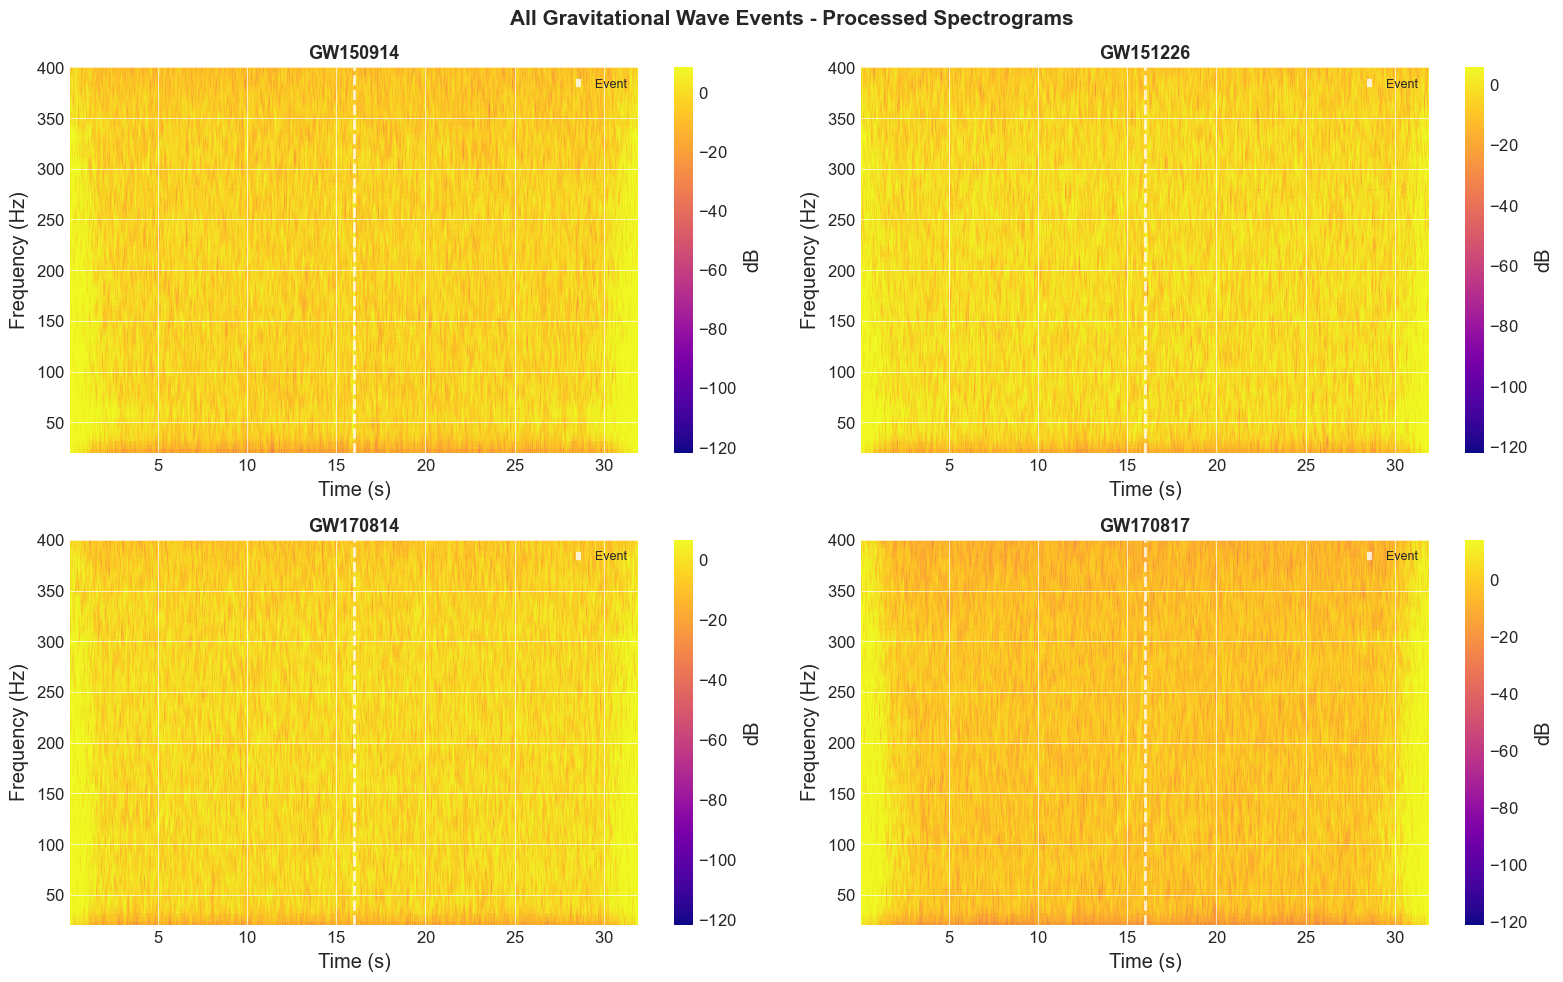


 Saved: 04_all_events.png


In [8]:
event_files  = sorted([f for f in glob.glob(os.path.join(EVENTS_DIR, '*_H1.npy'))
                        if 'meta' not in f])
event_names  = [os.path.basename(f).replace('_H1.npy', '') for f in event_files]

print(f"Plotting {len(event_names)} events...\n")

n_cols = 2
n_rows = (len(event_names) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for idx, event in enumerate(event_names):
    try:
        ev_data, ev_meta = load_event(event, 'H1')
        ev_processed     = preprocess(ev_data, fs=ev_meta['sample_rate'])
        
        f, t, Sxx = signal.spectrogram(
            ev_processed,
            fs=ev_meta['sample_rate'],
            nperseg=512,
            noverlap=480
        )
        
        Sxx_db = 10 * np.log10(Sxx + 1e-30)
        vmin   = np.percentile(Sxx_db, 5)
        vmax   = np.percentile(Sxx_db, 99)
        
        im = axes[idx].pcolormesh(t, f, Sxx_db,
                                   vmin=vmin, vmax=vmax,
                                   shading='gouraud', cmap='plasma')
        axes[idx].set_title(f'{event}', fontsize=13, fontweight='bold')
        axes[idx].set_xlabel('Time (s)')
        axes[idx].set_ylabel('Frequency (Hz)')
        axes[idx].set_ylim([20, 400])
        axes[idx].axvline(16, color='white', linestyle='--',
                          linewidth=2, alpha=0.8, label='Event')
        axes[idx].legend(fontsize=9)
        plt.colorbar(im, ax=axes[idx], label='dB')
        
        print(f"   {event} plotted")
        
    except Exception as e:
        print(f"   {event}: {e}")

for idx in range(len(event_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('All Gravitational Wave Events - Processed Spectrograms',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '04_all_events.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\n Saved: 04_all_events.png")

In [16]:

print(" PHASE 2: VISUALIZATION COMPLETE!")


saved = sorted(glob.glob(os.path.join(RESULTS_DIR, '*.png')))
print(f"\n Figures saved: {len(saved)}")
for f in saved:
    size = os.path.getsize(f) / 1024
    print(f"    {os.path.basename(f):40s} {size:.0f} KB")

print(f"\n Location: {RESULTS_DIR}")
print("\n Key takeaways:")
print("   • Raw data = blue blank images (noise dominates everything)")
print("   • Whitening = normalize noise across frequencies")
print("   • Bandpass  = keep only 30-400 Hz (GW range)")
print("   • Result    = chirp pattern clearly visible!")
print("\n Next: Phase 3 - Building the ML Dataset!")


 PHASE 2: VISUALIZATION COMPLETE!

 Figures saved: 12
    01_before_after.png                      414 KB
    01_raw_timeseries.png                    392 KB
    02_processed_spectrograms.png            1898 KB
    02_zoomed_timeseries.png                 241 KB
    03_signal_vs_noise.png                   808 KB
    03_spectrograms.png                      116 KB
    04_all_events.png                        1910 KB
    04_signal_vs_noise.png                   309 KB
    05_all_events.png                        150 KB
    06_enhanced_spectrogram.png              1407 KB
    07_qtransform.png                        661 KB
    09_dataset_samples.png                   963 KB

 Location: C:\Users\srika\gw_wd\results\figures

 Key takeaways:
   • Raw data = blue blank images (noise dominates everything)
   • Whitening = normalize noise across frequencies
   • Bandpass  = keep only 30-400 Hz (GW range)
   • Result    = chirp pattern clearly visible!

 Next: Phase 3 - Building the ML Dataset!